In [2]:
!pip install xgboost 

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 7.4 MB/s eta 0:00:10
   - -------------------------------------- 2.1/69.5 MB 5.1 MB/s eta 0:00:14
   - -------------------------------------- 2.6/69.5 MB 4.7 MB/s eta 0:00:15
   - -------------------------------------- 2.6/69.5 MB 4.7 MB/s eta 0:00:15
   - -------------------------------------- 2.9/69.5 MB 2.7 MB/s eta 0:00:25
   - -------------------------------------- 2.9/69.5 MB 2.7 MB/s eta 0:00:25
   - -------------------------------------- 3.1/69.5 MB 2.1 MB/s eta 0:00:32
   - -------------------------------------- 3.4/69.5 MB 2.1 MB/s eta 0:00:33
   -- ------------------------------------- 3.7/69.5 MB 2.0 MB/s eta 0:00:33
   -- ------------------------------------- 4.2/69.5 MB 2.0 MB/s eta 0:00:33
   -- ------------------------------------- 4.7/69.5 MB 2.1 MB/s eta 0:00:32
   --

In [5]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [6]:
# Training some Machine Learning Model (XGBoost , Random Forest) on the PIMA India Diabetes Database
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

base_url = "./"
# Load Dataset
# df = pd.read_csv(f"{base_url}/diabetes_generated.csv")
df = pd.read_csv(f"{base_url}/diabetes.csv")

print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [7]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# SMOTE (only on training)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)



In [8]:

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

lr_preds = lr.predict(X_test_scaled)

print(" Logistic Regression  ")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))


 Logistic Regression  
Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       100
           1       0.62      0.81      0.70        54

    accuracy                           0.76       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.76      0.76       154



In [10]:


# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)
rf.fit(X_train_res, y_train_res)

rf_preds = rf.predict(X_test_scaled)

print("\n Random Forest ")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))



 Random Forest 
Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       100
           1       0.78      0.83      0.80        54

    accuracy                           0.86       154
   macro avg       0.84      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_res, y_train_res)

y_pred = xgb.predict(X_test_scaled)

print(" Final XGBoost ")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

 Final XGBoost 
Accuracy: 0.8701298701298701
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       100
           1       0.79      0.85      0.82        54

    accuracy                           0.87       154
   macro avg       0.85      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154



                    Feature  Importance
4                   Insulin    0.372270
3             SkinThickness    0.149074
1                   Glucose    0.124783
7                       Age    0.091227
5                       BMI    0.081372
0               Pregnancies    0.063342
6  DiabetesPedigreeFunction    0.062323
2             BloodPressure    0.055610


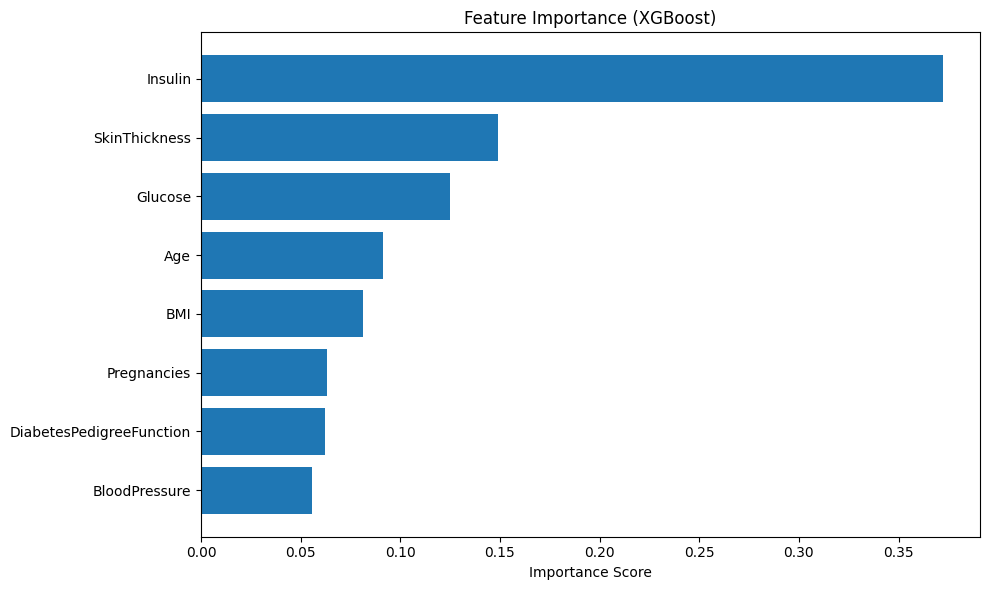

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

importances = xgb.feature_importances_
feature_names = X.columns

# Dataframe for clean view
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [38]:
# Dumping the XGBoost  (since it gave the highest Accuracy) 
import joblib

joblib.dump({
    "model": xgb,
    "scaler": scaler
}, f"{base_url}/diabetes_model.pkl")

print(" Model saved Successfully")

 Model saved Successfully
